<a href="https://colab.research.google.com/github/himanshibawa909-droid/big-data-code/blob/main/AIandNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import Libraries

In [ ]:

# Import Required Libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.metrics import confusion_matrix
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.19.0


In [ ]:
# 2. Load MNIST Dataset

In [ ]:

# Load Dataset


(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


In [ ]:
# 3. Data Preprocessing

In [ ]:

# Normalize Pixel Values


X_train = X_train / 255.0
X_test = X_test / 255.0

print("Pixel Range After Normalization:",
      X_train.min(), "to", X_train.max())


Pixel Range After Normalization: 0.0 to 1.0


In [ ]:
# 4. One-Hot Encode Labels

In [ ]:

# One-Hot Encoding


y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Example Encoded Label:", y_train[0])


Example Encoded Label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [ ]:
# 5. Build Neural Network Function

In [ ]:

# Build Model Function


def build_model(activation_function):

    model = Sequential([
        Flatten(input_shape=(28, 28)),

        # Six Hidden Layers
        Dense(128, activation=activation_function),
        Dense(128, activation=activation_function),
        Dense(64, activation=activation_function),
        Dense(64, activation=activation_function),
        Dense(32, activation=activation_function),
        Dense(32, activation=activation_function),

        # Output Layer
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
# 6. Train Model – Sigmoid

In [ ]:
print("\nTraining with SIGMOID activation...\n")

sigmoid_model = build_model("sigmoid")

sigmoid_model.summary()

history_sigmoid = sigmoid_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.4,
    verbose=1
)

sigmoid_loss, sigmoid_acc = sigmoid_model.evaluate(X_test, y_test)

print("\nSigmoid Test Accuracy:", round(sigmoid_acc, 4))



Training with SIGMOID activation...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,874 (519.04 KB)

 Trainable params: 132,874 (519.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2076 - loss: 2.0937 - val_accuracy: 0.4697 - val_loss: 1.3029
Epoch 2/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5245 - loss: 1.1888 - val_accuracy: 0.7062 - val_loss: 0.8254
Epoch 3/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7548 - loss: 0.7426 - val_accuracy: 0.8720 - val_loss: 0.5304
Epoch 4/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8914 - loss: 0.4521 - val_accuracy: 0.9098 - val_loss: 0.3735
Epoch 5/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9276 - loss: 0.3097 - val_accuracy: 0.9183 - val_loss: 0.3321
Epoch 6/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9417 - loss: 0.2404 - val_accuracy: 0.9247 - val_loss: 0.2909
Epoch 7/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9488 - loss: 0.2036 - val_accuracy: 0.9243 - val_loss: 0.2844
Epoch 8/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9568 - loss: 0.1706 - val_accuracy: 0.

In [ ]:
# 7. Train Model – Tanh

In [ ]:
print("\nTraining with TANH activation...\n")

tanh_model = build_model("tanh")

tanh_model.summary()

history_tanh = tanh_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.4,
    verbose=1
)

tanh_loss, tanh_acc = tanh_model.evaluate(X_test, y_test)

print("\nTanh Test Accuracy:", round(tanh_acc, 4))



Training with TANH activation...



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,874 (519.04 KB)

 Trainable params: 132,874 (519.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8149 - loss: 0.6922 - val_accuracy: 0.9359 - val_loss: 0.2164
Epoch 2/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9480 - loss: 0.1782 - val_accuracy: 0.9498 - val_loss: 0.1730
Epoch 3/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9623 - loss: 0.1236 - val_accuracy: 0.9561 - val_loss: 0.1508
Epoch 4/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9752 - loss: 0.0876 - val_accuracy: 0.9612 - val_loss: 0.1376
Epoch 5/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9778 - loss: 0.0754 - val_accuracy: 0.9638 - val_loss: 0.1263
Epoch 6/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9834 - loss: 0.0566 - val_accuracy: 0.9655 - val_loss: 0.1209
Epoch 7/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9842 - loss: 0.0524 - val_accuracy: 0.9668 - val_loss: 0.1218
Epoch 8/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9891 - loss: 0.0375 - val_accuracy: 0.

In [ ]:
# 8. Final Accuracy Comparison

In [ ]:
print("\nFinal Test Accuracy Comparison")
print("--------------------------------")
print("Sigmoid Accuracy:", round(sigmoid_acc, 4))
print("Tanh Accuracy:", round(tanh_acc, 4))



Final Test Accuracy Comparison
--------------------------------
Sigmoid Accuracy: 0.957
Tanh Accuracy: 0.9708


In [ ]:
# 9. Plot Accuracy Graph

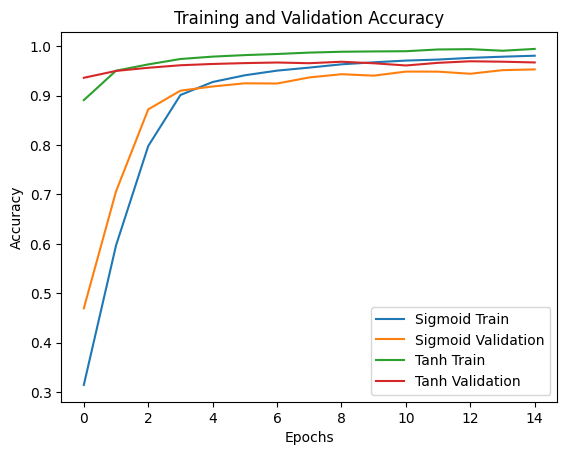

In [ ]:
plt.figure()
plt.plot(history_sigmoid.history['accuracy'], label='Sigmoid Train')
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid Validation')
plt.plot(history_tanh.history['accuracy'], label='Tanh Train')
plt.plot(history_tanh.history['val_accuracy'], label='Tanh Validation')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


In [ ]:
# 10. Plot Loss Graph

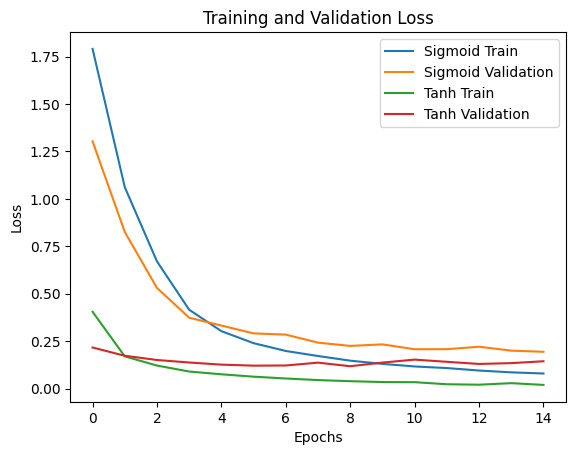

In [ ]:
plt.figure()
plt.plot(history_sigmoid.history['loss'], label='Sigmoid Train')
plt.plot(history_sigmoid.history['val_loss'], label='Sigmoid Validation')
plt.plot(history_tanh.history['loss'], label='Tanh Train')
plt.plot(history_tanh.history['val_loss'], label='Tanh Validation')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


In [ ]:
# 11. Confusion Matrix (Using Tanh Model)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


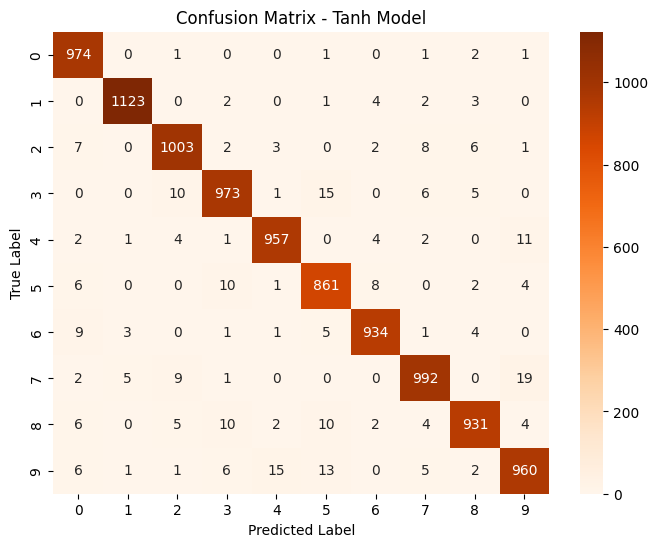

In [ ]:
# Get predictions
y_pred = tanh_model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Tanh Model")
plt.show()

In [ ]:
# 12. Show Sample Predictions

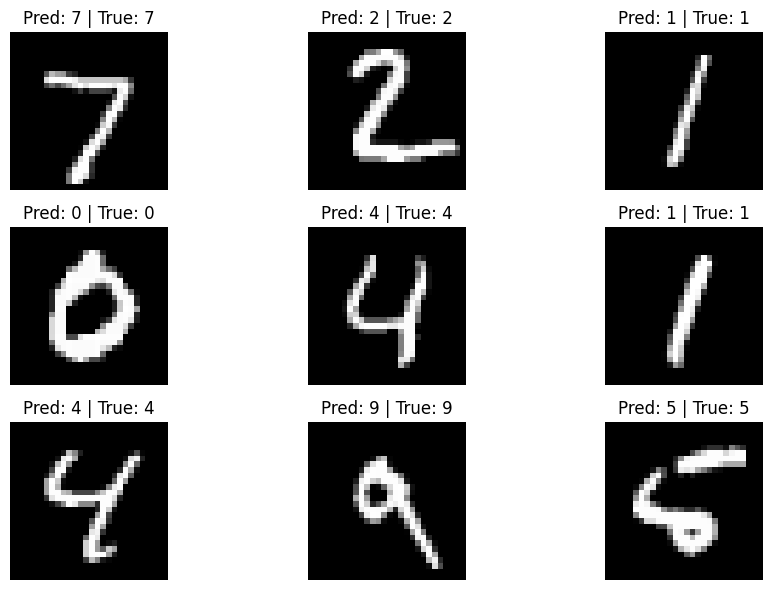

In [ ]:
plt.figure(figsize=(10,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Pred: {} | True: {}".format(
        y_pred_classes[i], y_true[i]))
    plt.axis('off')

plt.tight_layout()
plt.show()
